# 01 — Data Engineering & Exploratory Analytics

*E-commerce analytics pipeline: 34,500 raw transactions → schema-validated, RFM-engineered, production-ready*

## Executive Summary

Ingests **34,500 raw transactions across 730 days**, enforces a Pandera schema contract, engineers a 17-feature customer-level RFM table, and gates the result through an automated QA suite before persisting to Parquet. The dataset is clean at source — zero missing values, zero duplicate order IDs — and passes all 10 quality checks (7 clean passes, 3 benign dtype warnings). Non-normality confirmed across all four transaction variables, pre-authorising non-parametric tests in NB02 and NB03.

| Output | Dimensions | Size | Purpose |
|---|---|---|---|
| `enhanced_df.parquet` | 34,500 × 17 | 1.06 MB | Transaction-level data with enriched behavioural flags |
| `rfm_df.parquet` | 7,903 × 17 | 0.33 MB | Customer-level RFM + loyalty scores for clustering |

---

> **Assumptions to be aware of downstream:**
> - RFM `monetary` reflects *realised* revenue — returned orders excluded; `net_monetary` can go negative for return-heavy customers and is preserved as signal, not clipped
> - Reference date anchors to the dataset's latest order (2025-09-11), not wall-clock time — ensures reproducibility across runs
> - Customer demographics (age, gender, location) are mode-aggregated from per-transaction records; treat as directional
> - RFM loaded from cache (`rfm_cache_.parquet`) on this run — features were not recomputed fresh; valid, but downstream notebooks should note this

## 1. Environment Setup

`random_state = 42` seeded globally. Structured logging scoped to run ID. All thresholds and tunable parameters externalised to `config.yaml` — nothing hardcoded downstream.

In [ ]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import hashlib
from pathlib import Path
import sys
import random

# Statistical testing
from scipy import stats
from scipy.stats import normaltest, shapiro, chi2_contingency, mannwhitneyu, kruskal
from scipy.stats.contingency import association

# Setup project paths
current_dir = Path.cwd()
if (current_dir.parent / 'src').exists():
    sys.path.insert(0, str(current_dir.parent / 'src'))
elif (current_dir / 'src').exists():
    sys.path.insert(0, str(current_dir / 'src'))
else:
    raise RuntimeError("Cannot find src directory. Run from notebooks/ or project root.")

# Custom utilities
from n1a_utils import (
    get_project_root, load_config, setup_logger,
    verify_project_structure, set_run_id, generate_run_id
)

# Generate unique run ID for traceability
RUN_ID = generate_run_id()
set_run_id(RUN_ID)

PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Setup logging
logger = setup_logger(__name__)
logger.info("=" * 60)
logger.info("NOTEBOOK 01: Data Engineering & Customer Analytics")
logger.info("=" * 60)
logger.info(f"Project root: {PROJECT_ROOT}")
logger.info(f"Run ID: {RUN_ID}")

# Verify project structure
verify_project_structure(PROJECT_ROOT)
logger.info("Project structure verified")

# Global display configuration
warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette("muted")
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)
%matplotlib inline

# Load configuration
config   = load_config(PROJECT_ROOT / 'config.yaml')
nb1_cfg  = config.get('notebook1', {})
disp_cfg = nb1_cfg.get('display', {})
rules    = nb1_cfg.get('business_rules', {})
tests    = nb1_cfg.get('statistical_tests', {})
logger.info("Configuration loaded")

# Override display options from config where set
if disp_cfg.get('max_columns') is not None:
    pd.set_option('display.max_columns', disp_cfg['max_columns'])
if disp_cfg.get('max_rows') is not None:
    pd.set_option('display.max_rows', disp_cfg['max_rows'])

# Set random seed for reproducibility
RANDOM_SEED = config['notebook1']['random_state']
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
logger.info(f"Random seed set to: {RANDOM_SEED}")
logger.info("=" * 60)

print(f"\nSetup complete!")
print(f"Run ID:      {RUN_ID}")
print(f"Random seed: {RANDOM_SEED} (ensures reproducibility)")
print(f"Config loaded from: {PROJECT_ROOT / 'config.yaml'}")


[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - NOTEBOOK 01: Data Engineering & Customer Analytics
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - Project root: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - Run ID: 4be2aa58
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - Project structure verified
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - Configuration loaded
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - Random seed set to: 42
[4be2aa58] 2026-02-27 00:29:27 - __main__ - INFO - ============================================================



Setup complete!
Run ID:      4be2aa58
Random seed: 42 (ensures reproducibility)
Config loaded from: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\config.yaml


## 2. Data Ingestion

Schema-validated load via Pandera against a 17-column contract. **34,500 rows × 17 columns (17.56 MB)** loaded in a single chunk. Date range: 2023-09-12 → 2025-09-11 · 7,903 unique customers · 4.37 avg orders per customer.

Any type violation or out-of-range value would surface here — before a single feature is computed.

In [1]:
from n1b_data_loader import load_raw_data

# Load with schema validation
df_raw = load_raw_data(run_id=RUN_ID)

# Business context: expected data characteristics
expected_rows      = config['validation']['expected_row_count']
expected_customers = config['validation']['expected_customers']

print(f"\n{'='*80}")
print("DATA LOADING SUMMARY".center(80))
print("=" * 80)
print(f"\nData loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Expected: {expected_rows:,} rows | Actual: {df_raw.shape[0]:,} | Delta: {df_raw.shape[0] - expected_rows:+,}")
print(f"\nDate range: {df_raw['order_date'].min().date()} → {df_raw['order_date'].max().date()}")
print(f"Unique customers: {df_raw['customer_id'].nunique():,}")
print(f"Expected customers: {expected_customers:,}")
print(f"Avg orders per customer: {len(df_raw) / df_raw['customer_id'].nunique():.1f}")
print("=" * 80)


[4be2aa58] 2026-02-27 00:29:27 - n1b_data_loader - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:27 - n1b_data_loader - INFO - Starting Data Load Process
[4be2aa58] 2026-02-27 00:29:27 - n1b_data_loader - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Data source: ecommerce_sales_34500.csv
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Reading data in chunks of 100,000 rows
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Processing chunk 1...
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Concatenating 1 chunks...
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Data concatenation complete: 34,500 total rows
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Loading schema validation rules...
[4be2aa58] 2026-02-27 00:29:28 - n1b_data_loader - INFO - Schema loaded: 17 column validations
[4be2aa58] 2026-02-27 00:2


                              DATA LOADING SUMMARY                              

Data loaded: 34,500 rows x 17 columns
Expected: 34,500 rows | Actual: 34,500 | Delta: +0

Date range: 2023-09-12 → 2025-09-11
Unique customers: 7,903
Expected customers: 7,903
Avg orders per customer: 4.4


### 2.1 Missing Data Audit

**Zero missing values** across all 586,500 cells (34,500 × 17). No imputation required. Logged explicitly so any future data drift is immediately visible as a delta from this baseline.

In [2]:
from n1b_missing_data_analysis import analyze_missing_patterns

logger.info("Starting missing data analysis")

# Analyze missing patterns in raw data
missing_analysis_results = analyze_missing_patterns(
    df=df_raw,
    config=config,
    plot=True,
    verbose=True
)

# Store results for documentation
missing_summary = missing_analysis_results['summary']

if missing_summary['missing_cells'] == 0:
    logger.info("Data quality check: No missing values detected")
    print("\nDATA QUALITY: 100% complete - no imputation needed")
else:
    logger.warning(f"Missing data detected: {missing_summary['missing_percentage']:.2f}%")
    print(f"\nMISSING DATA FOUND:")
    print(f"Columns affected: {missing_summary['columns_with_missing']}")
    print(f"Recommended actions: {len(missing_analysis_results['recommendations'])}")

    # Print recommendations
    for rec in missing_analysis_results['recommendations']:
        print(f"\n{rec['column']}:")
        print(f"  Strategy:  {rec['strategy']}")
        print(f"  Rationale: {rec['rationale']}")


[4be2aa58] 2026-02-27 00:29:28 - __main__ - INFO - Starting missing data analysis
[4be2aa58] 2026-02-27 00:29:28 - __main__ - INFO - Data quality check: No missing values detected



                             MISSING DATA ANALYSIS                              

Overall Summary:
  Total cells      : 586,500
  Missing cells    : 0 (0.00%)
  Complete rows    : 34,500 (100.0%)
  Rows w/ missing  : 0 (0.0%)

  No missing data detected!

DATA QUALITY: 100% complete - no imputation needed


## 3. Cleaning Pipeline

Four-stage pipeline: deduplication → type coercion → business rule enforcement → integrity assertions.

**Result: zero rows removed — 34,500 retained (100%).** All dates valid, no negative `total_amount` / `price` / `shipping_cost`, 4 categorical columns standardised to consistent casing, `returned` flag binarised to 0/1. The pipeline is a no-op on this dataset — documented explicitly so any future data drift is immediately visible as a delta from this baseline.

In [3]:
from n1c_preprocessing import clean_data

df_clean = clean_data(df_raw, verbose=True, run_id=RUN_ID)

# Quality metrics: document data cleaning impact
rows_removed = len(df_raw) - len(df_clean)
removal_rate = (rows_removed / len(df_raw)) * 100
max_loss     = rules.get('max_acceptable_data_loss_pct', 5.0)

print(f"\n{'='*80}")
print("CLEANING IMPACT ANALYSIS".center(80))
print("=" * 80)
print(f"\nRows removed: {rows_removed:,} ({removal_rate:.2f}%)")
print(f"Rows retained: {len(df_clean):,} ({100 - removal_rate:.2f}%)")

if removal_rate > max_loss:
    print(f"\nWARNING: Data loss exceeds {max_loss:.0f}% threshold")
    print(f"Action required: Investigate root cause of {removal_rate:.1f}% data loss")
else:
    print(f"\nData loss within acceptable range (< {max_loss:.0f}%)")

print(f"\nMissing values: {df_clean.isnull().sum().sum()} (target: 0)")
print(f"Duplicate order IDs: {df_clean['order_id'].duplicated().sum()} (target: 0)")
print("=" * 80)


[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Starting data cleaning process
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Input shape: 34,500 rows x 17 columns
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Numeric strategy   : median
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Categorical strategy: mode
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - No duplicate order_id rows found
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Processing date columns:
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - All dates valid
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Standardised 4 categorical columns
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Processing returned flag:
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - Converted returned flag to binary (0/1)
[4be2aa58] 2026-02-27 00:29:28 - n1c_preprocessing - INFO - No missing values to impute
[4be2aa58] 20


                            CLEANING IMPACT ANALYSIS                            

Rows removed: 0 (0.00%)
Rows retained: 34,500 (100.00%)

Data loss within acceptable range (< 5%)

Missing values: 0 (target: 0)
Duplicate order IDs: 0 (target: 0)


## 4. RFM Feature Engineering

Aggregates 34,500 transaction records into a **7,903-row customer-level analytical base table**. Core RFM metrics plus 14 behavioural features:

| Feature | Definition | Note |
|---|---|---|
| `recency_days` | Days since last *successful* purchase | Completed orders only |
| `frequency` | Count of completed orders | Returns excluded |
| `monetary` | Gross revenue contribution | Returns excluded |
| `net_monetary` | Revenue net of returns | Can be negative — preserved as signal |
| `loyalty_score` | Weighted composite R:30% / F:40% / M:30%, normalised [0, 1] | Mean = 0.385 |
| `tenure_days` | Days from first to last order | Mean 411 days |
| `category_diversity` | Unique categories purchased | Mean 3.1 of 7 |
| `churn` | Binary: recency > 120 days **or** pure-return customer | Threshold: `config.yaml → rfm.churn_threshold_days` |

Both the churn threshold (120 days) and loyalty weights (R: 0.3 · F: 0.4 · M: 0.3) are fully config-driven — edit `config.yaml` to adjust without touching code.

In [4]:
from n1d_rfm_features import build_rfm_features, clear_old_cache, clear_rfm_cache

# Clear old cache to ensure fresh calculation
clear_old_cache(ttl_hours=24)

# Generate config hash for cache keying
import hashlib
rfm_config_str = str(config.get('rfm', {}))
config_hash = hashlib.md5(rfm_config_str.encode()).hexdigest()[:8]

# Build RFM features
rfm_df = build_rfm_features(
    df=df_clean,
    config_hash=config_hash,
    verbose=True,
    run_id=RUN_ID,
    use_cache=True
)

print(f"\nRFM features generated: {rfm_df.shape[0]:,} customers x {rfm_df.shape[1]} features")


[4be2aa58] 2026-02-27 00:29:28 - n1d_rfm_features - INFO - No cache files older than 24h
[4be2aa58] 2026-02-27 00:29:28 - n1d_rfm_features - INFO - Starting RFM feature engineering
[4be2aa58] 2026-02-27 00:29:28 - n1d_rfm_features - INFO - Input shape: 34,500 rows x 17 columns
[4be2aa58] 2026-02-27 00:29:28 - n1d_rfm_features - INFO - Unique customers: 7,903
[4be2aa58] 2026-02-27 00:29:28 - n1d_rfm_features - INFO - Loading cached RFM features from rfm_cache_559db890.parquet
[4be2aa58] 2026-02-27 00:29:28 - n1d_rfm_features - INFO - Loaded cached features: 7,903 customers



RFM features generated: 7,903 customers x 17 features


### 4.1 Engineering Decisions & Edge Cases

**Negative `net_monetary` — preserved, not clipped.**
388 customers returned more than they purchased in net terms (floor: −$5,060.52). Clipping to zero would erase this cohort entirely; the negative value is the signal.

**Pure-return customers — retained for auditability, excluded from modelling.**
26 customers have zero successful purchases; RFM metrics are `NaN` for this cohort. They remain in `rfm_df` but are flagged and excluded from distance-based modelling in NB03.

**`recency_days` vs. `last_order_was_return` — orthogonal signals.**
`recency_days` keys on the last *completed* purchase. `last_order_was_return` (436 customers) captures whether the most recent *any* transaction was a return. Conflating them would misclassify engaged customers who happened to return their last item.

In [5]:
# Negative net_monetary customers
neg_net = rfm_df[rfm_df['net_monetary'] < 0]
print(f"Negative net_monetary customers : {len(neg_net):,}")
print(f"  Revenue range                 : ${neg_net['net_monetary'].min():,.2f} to ${neg_net['net_monetary'].max():,.2f}")

# Pure-return customers (NaN RFM core metrics)
pure_return = rfm_df[rfm_df['recency_days'].isna()]
print(f"\nPure-return customers (NaN RFM) : {len(pure_return):,}")
print(f"  Churn flag                    : {pure_return['churn'].sum():.0f}/"
      f"{len(pure_return)} flagged churned")

# Customers whose last transaction was a return
last_was_return = rfm_df[rfm_df['last_order_was_return'] == 1]
print(f"\nLast order was a return         : {len(last_was_return):,} customers")
print(f"  Share of total cohort         : {len(last_was_return)/len(rfm_df)*100:.1f}%")


Negative net_monetary customers : 388
  Revenue range                 : $-5,060.52 to $-0.44

Pure-return customers (NaN RFM) : 26
  Churn flag                    : 26/26 flagged churned

Last order was a return         : 436 customers
  Share of total cohort         : 5.5%


## 5. Exploratory Data Analysis

### 5.1 Transaction-Level Distributions

All four transaction variables are **non-normal** (Shapiro-Wilk on 5,000-row sample per variable, p < 0.001 for all — `config: statistical_tests.normality_sample_size: 5000`). This pre-authorises non-parametric tests (Mann-Whitney U, Kruskal-Wallis) throughout NB02 and NB03. Parametric equivalents (ANOVA, t-test) would be inappropriate here.

**On the IQR outlier flags:** Four variables were flagged, but not all flags are genuine outliers.

| Variable | Flagged | Rate | Verdict |
|---|---|---|---|
| `total_amount` | 3,792 | 11.0% | Genuine high-value orders — keep, assess before clustering |
| `quantity` | 2,070 | 6.0% | IQR artifact — values 4–5 on a 1–5 discrete scale, not outliers |
| `discount` | 704 | 2.0% | IQR artifact — exactly the 30% discount tier, not outliers |
| `shipping_cost` | 48 | 0.1% | Genuinely anomalous — flagged for review |

[4be2aa58] 2026-02-27 00:29:28 - n1e_viz_exploration_utils - INFO - Figures directory configured: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures
[4be2aa58] 2026-02-27 00:29:28 - n1e_viz_exploration_utils - INFO - Plotting 4 of 4 distributions


                    TRANSACTION-LEVEL DISTRIBUTION ANALYSIS                     


[4be2aa58] 2026-02-27 00:29:30 - n1e_viz_exploration_utils - INFO - Figure saved: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures\notebook1_fig\distribution_20260227_002929.png
[4be2aa58] 2026-02-27 00:29:30 - n1e_viz_exploration_utils - INFO - Distribution plots saved


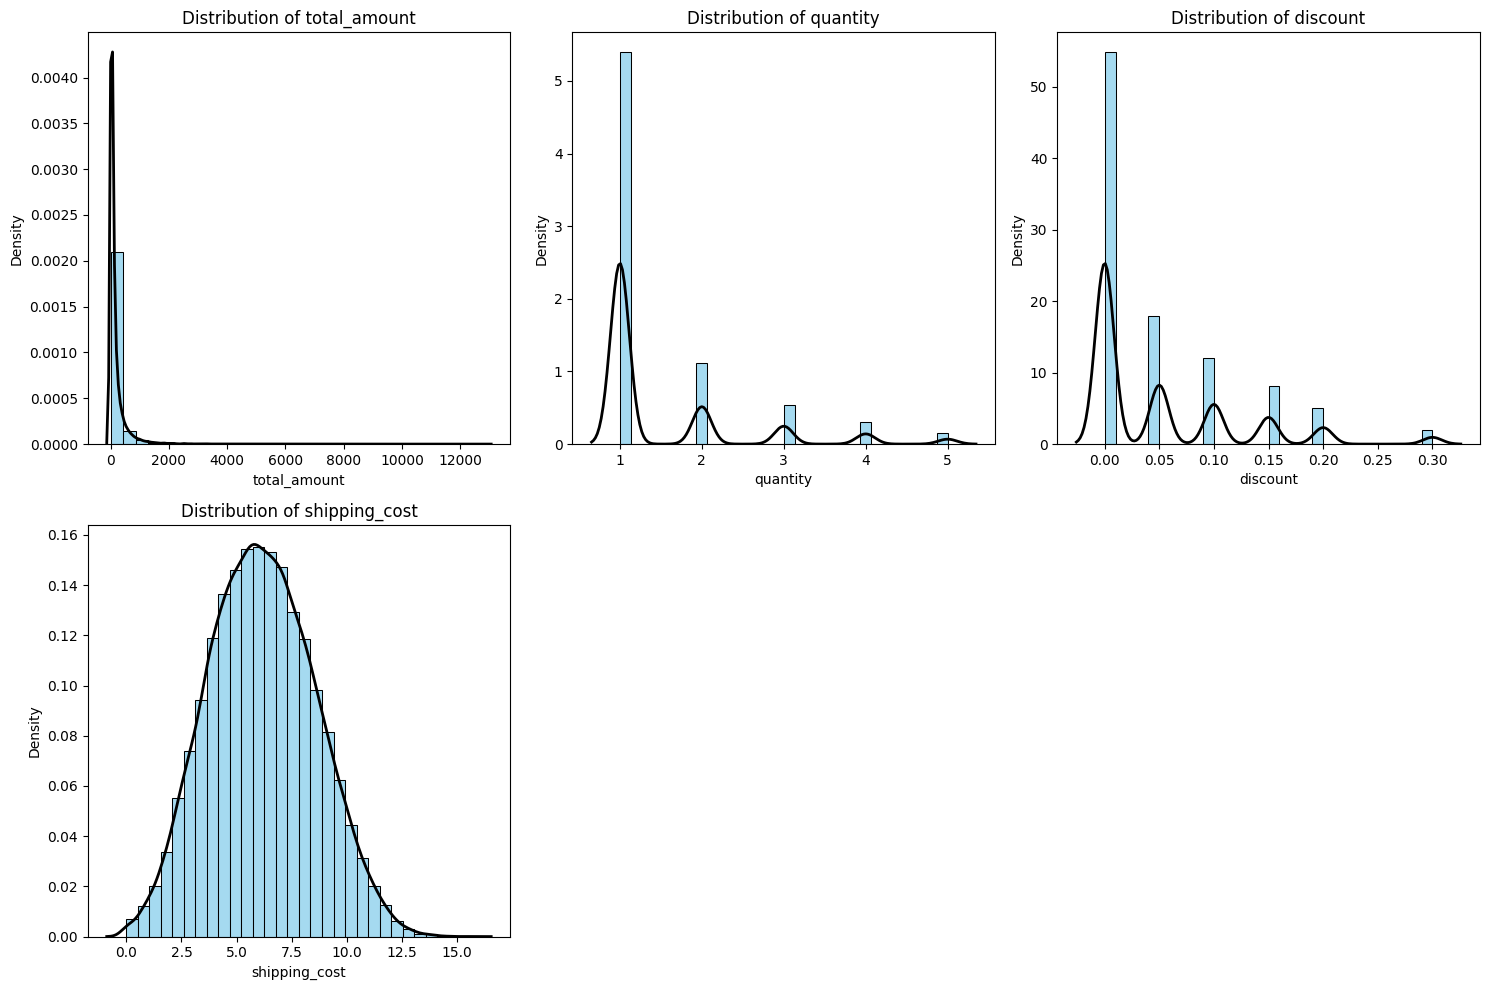

[4be2aa58] 2026-02-27 00:29:30 - n1e_viz_exploration_utils - INFO - Distribution plots complete



Normality Tests (Shapiro-Wilk):
--------------------------------------------------------------------------------
  ✗ total_amount        : p=0.0000 → Non-Normal
Use non-parametric tests (Mann-Whitney, Kruskal-Wallis)
  ✗ quantity            : p=0.0000 → Non-Normal
Use non-parametric tests (Mann-Whitney, Kruskal-Wallis)
  ✗ discount            : p=0.0000 → Non-Normal
Use non-parametric tests (Mann-Whitney, Kruskal-Wallis)
  ✗ shipping_cost       : p=0.0000 → Non-Normal
Use non-parametric tests (Mann-Whitney, Kruskal-Wallis)



In [6]:
from n1e_viz_exploration_utils import (
    plot_distribution, plot_boxplots,
    plot_correlation_heatmap, plot_categorical_counts, 
    interpret_cramers_v
)

subfolder        = "notebook1_fig"
transaction_cols = nb1_cfg.get('eda', {}).get('transaction_cols',
                    ['total_amount', 'quantity', 'discount', 'shipping_cost'])
normality_n      = tests.get('normality_sample_size', 5000)
normality_alpha  = tests.get('normality_alpha', 0.05)

print("=" * 80)
print("TRANSACTION-LEVEL DISTRIBUTION ANALYSIS".center(80))
print("=" * 80)

plot_distribution(
    df_clean,
    columns=transaction_cols,
    save=True,
    show=True,
    subfolder=subfolder,
    run_id=RUN_ID
)

# Statistical analysis: test for normality
print("\nNormality Tests (Shapiro-Wilk):")
print("-" * 80)
for col in transaction_cols:
    # Sample for large datasets (Shapiro-Wilk has a sample size limit)
    sample = df_clean[col].dropna().sample(min(normality_n, len(df_clean)), random_state=RANDOM_SEED)
    stat, p_value = shapiro(sample)

    is_normal = "Normal"     if p_value > normality_alpha else "Non-Normal"
    symbol    = "✓"          if p_value > normality_alpha else "✗"

    print(f"  {symbol} {col:20s}: p={p_value:.4f} → {is_normal}")
    if p_value <= normality_alpha:
        print(f"Use non-parametric tests (Mann-Whitney, Kruskal-Wallis)")

print("\n" + "=" * 80)


[4be2aa58] 2026-02-27 00:29:30 - n1e_viz_exploration_utils - INFO - Creating 4 boxplots


                                OUTLIER ANALYSIS                                


[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Figure saved: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures\notebook1_fig\boxplots_20260227_002930.png
[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Boxplots saved


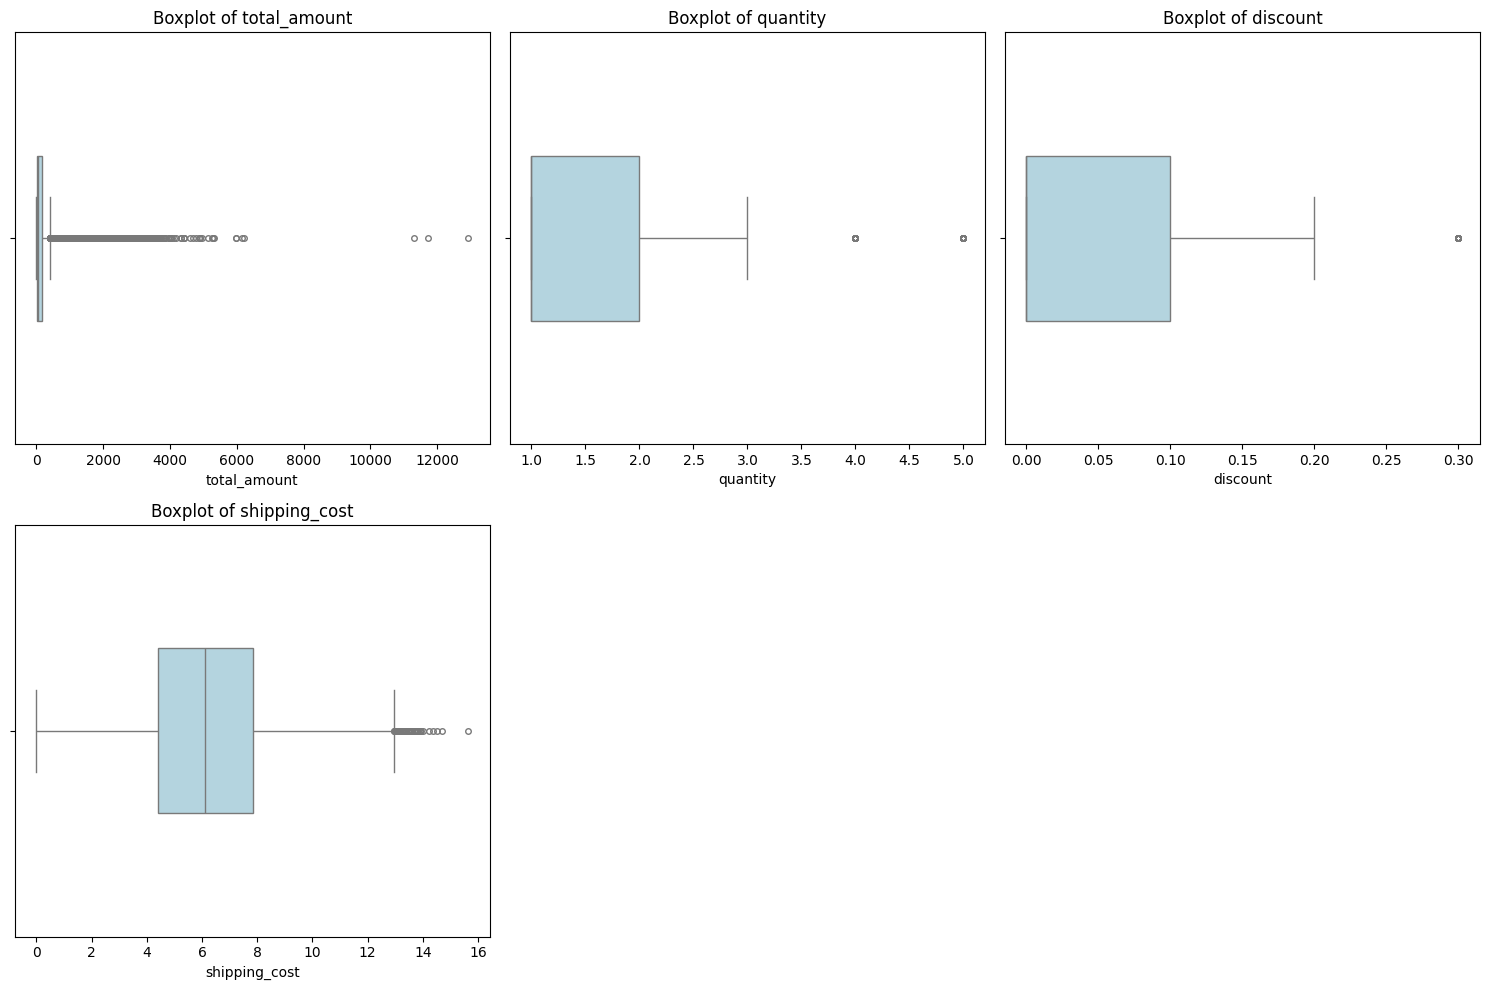

[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Boxplots complete



Outlier Detection (IQR Method):
--------------------------------------------------------------------------------
total_amount        : 3,792 outliers (10.99%)
High outlier rate
Range: [0.82, 12931.80]
Outlier range: [391.86, 12931.80]

quantity            : 2,070 outliers ( 6.00%)
High outlier rate
Range: [1.00, 5.00]
Outlier range: [4.00, 5.00]

discount            :   704 outliers ( 2.04%)
Range: [0.00, 0.30]
Outlier range: [0.30, 0.30]

shipping_cost       :    48 outliers ( 0.14%)
Range: [0.00, 15.65]
Outlier range: [12.95, 15.65]



In [7]:
# Outlier detection with business context
iqr_multiplier      = nb1_cfg.get('outlier', {}).get('iqr_multiplier', 1.5)
high_outlier_thresh = rules.get('high_outlier_pct_threshold', 5.0)

print("=" * 80)
print("OUTLIER ANALYSIS".center(80))
print("=" * 80)

plot_boxplots(
    df_clean,
    columns=transaction_cols,
    save=True,
    show=True,
    subfolder=subfolder,
    run_id=RUN_ID
)

# Business insight: quantify outliers using IQR method
print("\nOutlier Detection (IQR Method):")
print("-" * 80)
for col in transaction_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_multiplier * IQR
    upper_bound = Q3 + iqr_multiplier * IQR

    outliers    = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df_clean)) * 100

    print(f"{col:20s}: {len(outliers):5,} outliers ({outlier_pct:5.2f}%)")

    if outlier_pct > high_outlier_thresh:
        print(f"High outlier rate")

    if len(outliers) > 0:
        print(f"Range: [{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]")
        print(f"Outlier range: [{outliers[col].min():.2f}, {outliers[col].max():.2f}]\n")


### 5.2 Customer-Level RFM Analysis

Right-skewed RFM distributions are **expected and structurally healthy** — they reflect the natural Pareto concentration of customer bases. The question is whether concentration is manageable or dangerously narrow.

| Metric | Skew | Key finding |
|---|---|---|
| `recency_days` | 1.31 | Mean 165 days vs. median 120 — 37% gap confirms a long tail of inactive customers |
| `monetary` | 3.57 | Top 9% of customers (≥$1,567 LTV, n=788) generate **36.3% of total revenue ($1.99M)** |
| `frequency` | 0.59 | Moderate — purchase behaviour is reasonably distributed |
| `loyalty_score` | −0.33 | Near-symmetric — most customers sit in the weak-to-moderate engagement band |

**Verdict on concentration:** Revenue is not dangerously over-concentrated. The top-decile generates 36.3% — significant, but not a single-customer dependency risk. Tiered retention strategies are viable across the full distribution.

[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Creating 4 boxplots


                           RFM DISTRIBUTION ANALYSIS                            
RFM Distribution Characteristics:
--------------------------------------------------------------------------------

recency_days        : Skewness =   1.31 -> Highly skewed → Right-skewed
  Many inactive customers; prioritize reactivation strategies
  Mean (165 days) > Median (120 days): some high-recency customers
  Target customers with recency > 120 days (above median)
  25% of customers inactive for 236+ days → urgent reactivation needed

frequency           : Skewness =   0.59 -> Moderately skewed → Right-skewed
  Moderate concentration of infrequent buyers
  Top 25% made 5+ purchases – leverage for advocacy and referrals

monetary            : Skewness =   3.57 -> Extremely skewed → Right-skewed
  Revenue concentrated in small customer segment (Pareto principle)
  Opportunity: upsell lower segments toward $903.80 (75th percentile)
  Target customers spending $450.97–$903.80

loyalty_score       : Ske

[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Figure saved: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures\notebook1_fig\boxplots_20260227_002931.png
[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Boxplots saved


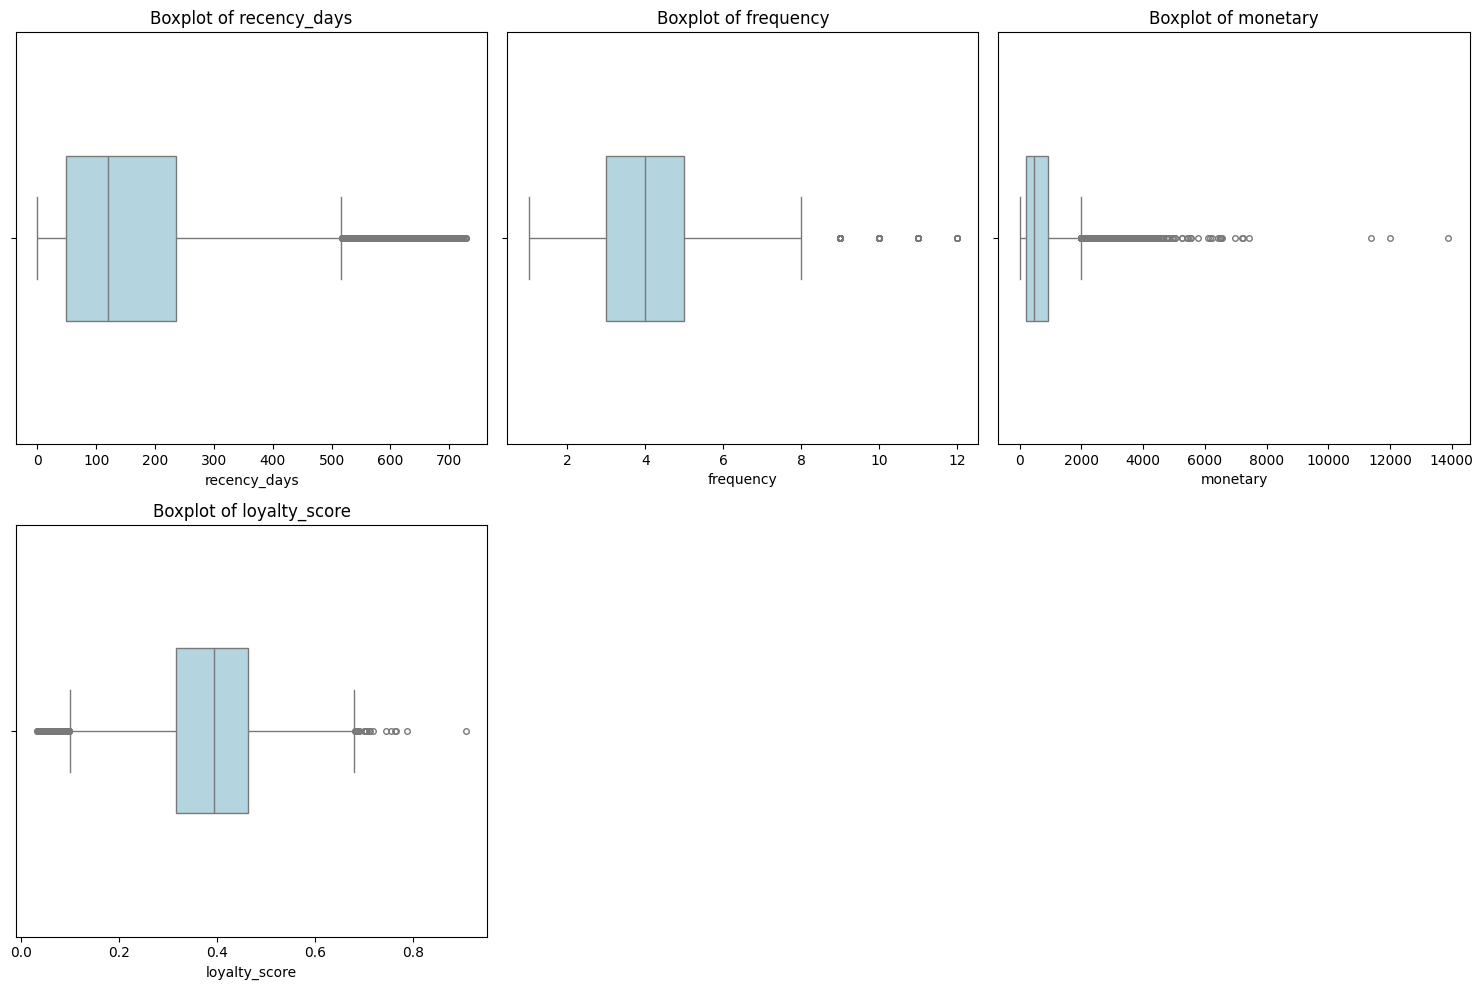

[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Boxplots complete



High-Value Customer Identification:
--------------------------------------------------------------------------------
Top 9% Customers (Monetary >= $1566.99):
  Count                : 788 customers
  Revenue contribution : $1,989,035.75
  % of total revenue   : 36.3%
  Avg frequency        : 5.7 orders
  Avg recency          : 123 days

HEALTHY DISTRIBUTION: top 9% generate 36% of revenue
  Revenue well-distributed; opportunity for tiered strategies



In [8]:
from n1e_viz_exploration_utils import (
    analyze_rfm_distributions,
    analyze_high_value_customers,
    plot_boxplots
    )

rfm_cols = nb1_cfg.get('eda', {}).get('rfm_cols',
            ['recency_days', 'frequency', 'monetary', 'loyalty_score'])

# 1. Dynamic RFM distribution analysis
rfm_analysis = analyze_rfm_distributions(
    rfm_df=rfm_df,
    run_id=RUN_ID,
    verbose=True
    )

# 2. Boxplots for outlier detection
plot_boxplots(
    df=rfm_df,
    columns=rfm_cols,
    save=True,
    show=True,
    subfolder=subfolder,
    run_id=RUN_ID
    )

# 3. High-value customer analysis
high_value_analysis = analyze_high_value_customers(
    rfm_df=rfm_df,
    percentile=0.90,
    run_id=RUN_ID,
    verbose=True
    )


### 5.3 Categorical Variable Analysis

**Return rates by category — statistically significant, practically negligible.**
Fashion leads (8.28%), Grocery trails (1.31%). The Chi-square test is significant (χ² = 296.80, df = 6, p < 0.001), but Cramér's V = 0.093 — a negligible effect size. At n = 34,500, the test detects real differences that are too small to drive strategy. Category-specific return interventions are not warranted from this data alone.

**Revenue concentration — the more pressing structural finding.**
Electronics alone generates $3,319,207 — **56.6% of total revenue** — at an AOV of $537.09 (3.2× the portfolio average). The top three categories together account for **85.7% of revenue**. This is a structural business risk: any disruption to Electronics demand, supply, or margin directly threatens the majority of revenue. Diversification is warranted regardless of Electronics' current performance.

[4be2aa58] 2026-02-27 00:29:31 - n1e_viz_exploration_utils - INFO - Plotting 4 categorical distributions


                         CATEGORICAL VARIABLE ANALYSIS                          


[4be2aa58] 2026-02-27 00:29:32 - n1e_viz_exploration_utils - INFO - Figure saved: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures\notebook1_fig\categorical_counts_20260227_002932.png
[4be2aa58] 2026-02-27 00:29:32 - n1e_viz_exploration_utils - INFO - Categorical count plots saved


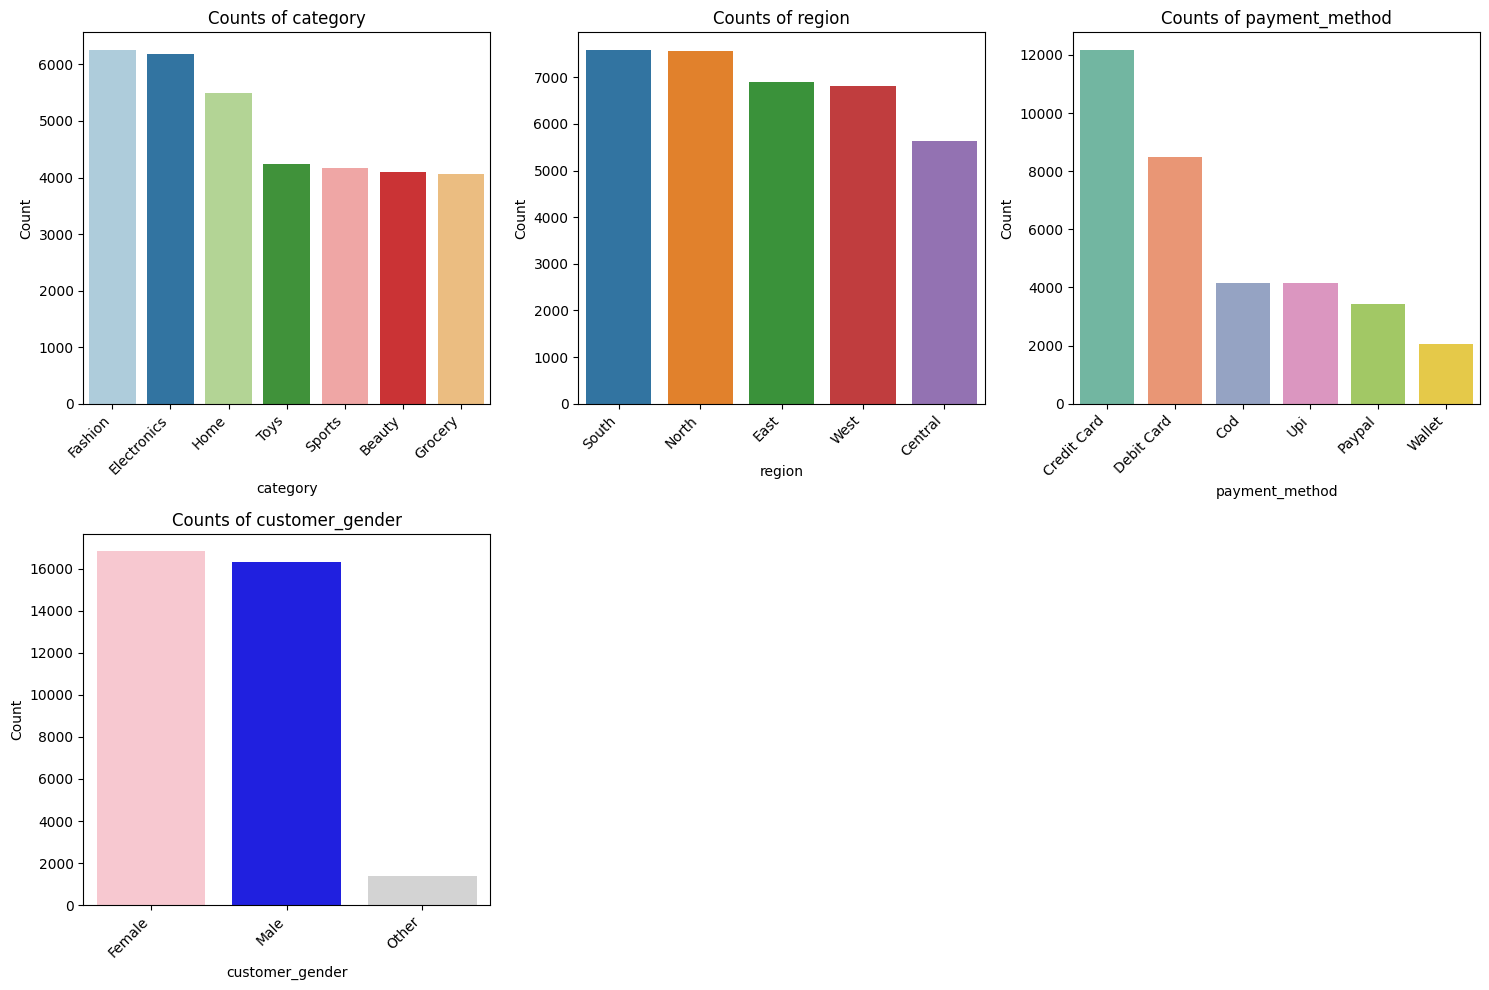

[4be2aa58] 2026-02-27 00:29:32 - n1e_viz_exploration_utils - INFO - Categorical count plots complete



Chi-Square Tests for Association:
--------------------------------------------------------------------------------

Category vs. Return Status:
  Chi-square statistic : 296.8033
  P-value              : 0.0000
  Degrees of freedom   : 6
  Cramér's V           : 0.0928  [Negligible association]

Expected frequencies:
returned           0      1
category                   
Beauty      3,876.68 226.32
Electronics 5,839.11 340.89
Fashion     5,909.03 344.97
Grocery     3,834.16 223.84
Home        5,184.34 302.66
Sports      3,940.93 230.07
Toys        4,012.74 234.26

SIGNIFICANT: Categories have different return rates (p < 0.05)
NOTE: Effect size is negligible (V=0.093) — statistically significant but likely driven by sample size; practical difference may be small.
Action: Investigate high-return categories for quality issues

Return Rates by Category:
    Fashion             :  8.28%
    Electronics         :  7.30%
    Home                :  5.65%
    Toys                :  4.94%
    S

In [9]:
categorical_cols = nb1_cfg.get('eda', {}).get('categorical_cols',
                    ['category', 'region', 'payment_method', 'customer_gender'])
chi_sq_alpha     = tests.get('chi_square_alpha', 0.05)

print("=" * 80)
print("CATEGORICAL VARIABLE ANALYSIS".center(80))
print("=" * 80)

plot_categorical_counts(
    df_clean,
    columns=categorical_cols,
    save=True,
    show=True,
    subfolder=subfolder,
    run_id=RUN_ID
)

# Statistical test: chi-square test for independence
print("\nChi-Square Tests for Association:")
print("-" * 80)

# Test: Is category distribution independent of return status?
contingency_table = pd.crosstab(df_clean['category'], df_clean['returned'])

# Chi2_contingency returns a named tuple in scipy >= 1.11 — unpack via attributes
chi2_result = chi2_contingency(contingency_table)
chi2_stat, p_value, dof, expected = (
    chi2_result.statistic,
    chi2_result.pvalue,
    chi2_result.dof,
    chi2_result.expected_freq,
)

# Cramér's V — effect size for the chi-square result above
cramers_v    = association(contingency_table, method="cramer")
effect_interp = interpret_cramers_v(cramers_v)

print(f"\nCategory vs. Return Status:")
print(f"  Chi-square statistic : {chi2_stat:.4f}")
print(f"  P-value              : {p_value:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  Cramér's V           : {cramers_v:.4f}  [{effect_interp['label']}]")
print(f"\nExpected frequencies:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))
print()

if p_value < chi_sq_alpha:
    print(f"SIGNIFICANT: Categories have different return rates (p < {chi_sq_alpha})")

    if effect_interp["strength"] in ("negligible", "weak"):
        print(
            f"NOTE: Effect size is {effect_interp['strength']} (V={cramers_v:.3f}) — "
            "statistically significant but likely driven by sample size; "
            "practical difference may be small."
        )
    else:
        print(
            f"Effect size is {effect_interp['strength']} (V={cramers_v:.3f}) — "
            "meaningful practical difference between categories."
        )

    print("Action: Investigate high-return categories for quality issues")

    # Show return rates by category
    return_rates = df_clean.groupby('category')['returned'].mean().sort_values(ascending=False)
    print(f"\nReturn Rates by Category:")
    for cat, rate in return_rates.items():
        symbol = "!!!" if rate > 0.10 else "   "
        print(f"{symbol} {cat:20s}: {rate*100:5.2f}%")
else:
    print(f"NOT SIGNIFICANT: Return rates similar across categories (p ≥ {chi_sq_alpha})")
    print(f"Effect size confirms: {effect_interp['label']} (V={cramers_v:.3f})")

print("=" * 80)

In [10]:
# Revenue analysis by category
conc_high     = rules.get('revenue_concentration_high', 40.0)
conc_moderate = rules.get('revenue_concentration_moderate', 25.0)

print("REVENUE ANALYSIS BY CATEGORY")
print("=" * 80)

category_revenue = df_clean.groupby('category').agg({
    'total_amount': ['sum', 'mean', 'count'],
    'returned':     'mean'
}).round(2)

category_revenue.columns = ['Total Revenue', 'Avg Order Value', 'Order Count', 'Return Rate']
category_revenue['Revenue %'] = (
    category_revenue['Total Revenue'] / category_revenue['Total Revenue'].sum() * 100
).round(1)
category_revenue = category_revenue.sort_values('Total Revenue', ascending=False)

display(category_revenue)

# Strategic insight: portfolio analysis
print("\nCategory Portfolio Insights:")
print("-" * 80)
top_category    = category_revenue.index[0]
top_revenue_pct = float(category_revenue.iloc[0]['Revenue %'])

print(f"Top Category: {top_category}")
print(f"Revenue contribution: {top_revenue_pct:.1f}%")

if top_revenue_pct > conc_high:
    print(f"HIGH DEPENDENCY (>{conc_high:.0f}%): Over-reliance on single category")
    print(f"Diversification strategy needed")
elif top_revenue_pct > conc_moderate:
    print(f"MODERATE CONCENTRATION (>{conc_moderate:.0f}%): Monitor category performance closely")
else:
    print(f"BALANCED PORTFOLIO: Revenue well-distributed across categories")

print("=" * 80)


REVENUE ANALYSIS BY CATEGORY


,Total Revenue,Avg Order Value,Order Count,Return Rate,Revenue %
category,,,,,
Electronics,"3,319,206.50",537.09,6180,0.07,56.60
Home,"1,077,681.50",196.41,5487,0.06,18.40
Sports,"629,825.56",151.00,4171,0.05,10.70
Fashion,"471,545.81",75.40,6254,0.08,8.00
Beauty,"153,019.38",37.29,4103,0.04,2.60
Toys,"132,013.80",31.08,4247,0.05,2.30
Grocery,"82,000.51",20.21,4058,0.01,1.40



Category Portfolio Insights:
--------------------------------------------------------------------------------
Top Category: Electronics
Revenue contribution: 56.6%
HIGH DEPENDENCY (>40%): Over-reliance on single category
Diversification strategy needed


### 5.4 Feature Correlation Structure

14 strong correlations (|r| > 0.5) identified. They validate engineered feature behaviour, confirm expected relationships, and flag collinearity pairs to exclude from modelling:

| Pair | r | Interpretation |
|---|---|---|
| `monetary` ↔ `net_monetary` | 0.967 | Near-duplicate — confirms net calculation is correct |
| `frequency` ↔ `loyalty_score` | 0.865 | Validates loyalty formula (frequency component dominates) |
| `frequency` ↔ `category_diversity` | 0.846 | Frequent buyers explore more categories |
| `recency_days` ↔ `loyalty_score` | −0.812 | Validates recency penalty in loyalty formula |
| `monetary` ↔ `avg_order_value` | 0.784 | Revenue driven by ticket size, not volume |
| `net_monetary` ↔ `avg_order_value` | 0.760 | Expected by construction |
| `recency_days` ↔ `churn` | 0.746 | Recency is the primary churn predictor — validates churn definition |
| `category_diversity` ↔ `loyalty_score` | 0.743 | Category exploration is a strong loyalty indicator |
| `tenure_days` ↔ `loyalty_score` | 0.725 | Longer-tenured customers are more loyal |
| `recency_days` ↔ `tenure_days` | −0.625 | Long-tenured customers remain more recently engaged |
| `frequency` ↔ `tenure_days` | 0.620 | Customer lifetime drives repeat purchase accumulation |
| `loyalty_score` ↔ `churn` | −0.610 | Loyalty score is a strong inverse churn predictor — validated |
| `tenure_days` ↔ `category_diversity` | 0.570 | Longer tenure → broader category exploration over time |
| `return_rate` ↔ `last_order_was_return` | 0.556 | Return behaviour is consistent per customer |

**Two collinear pairs to manage in modelling:**
`monetary`/`net_monetary` (r = 0.967) and `frequency`/`loyalty_score` (r = 0.865). NB03 retains `monetary` and `loyalty_score` as representatives and drops the others. `avg_order_value` is also excluded — it tracks too closely with `monetary` (r = 0.784) to add independent clustering signal.

[4be2aa58] 2026-02-27 00:29:32 - n1e_viz_exploration_utils - INFO - Computing correlations for 13 numeric columns
[4be2aa58] 2026-02-27 00:29:33 - n1e_viz_exploration_utils - INFO - Figure saved: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\outputs\figures\notebook1_fig\correlation_heatmap_20260227_002932.png
[4be2aa58] 2026-02-27 00:29:33 - n1e_viz_exploration_utils - INFO - Correlation heatmap saved


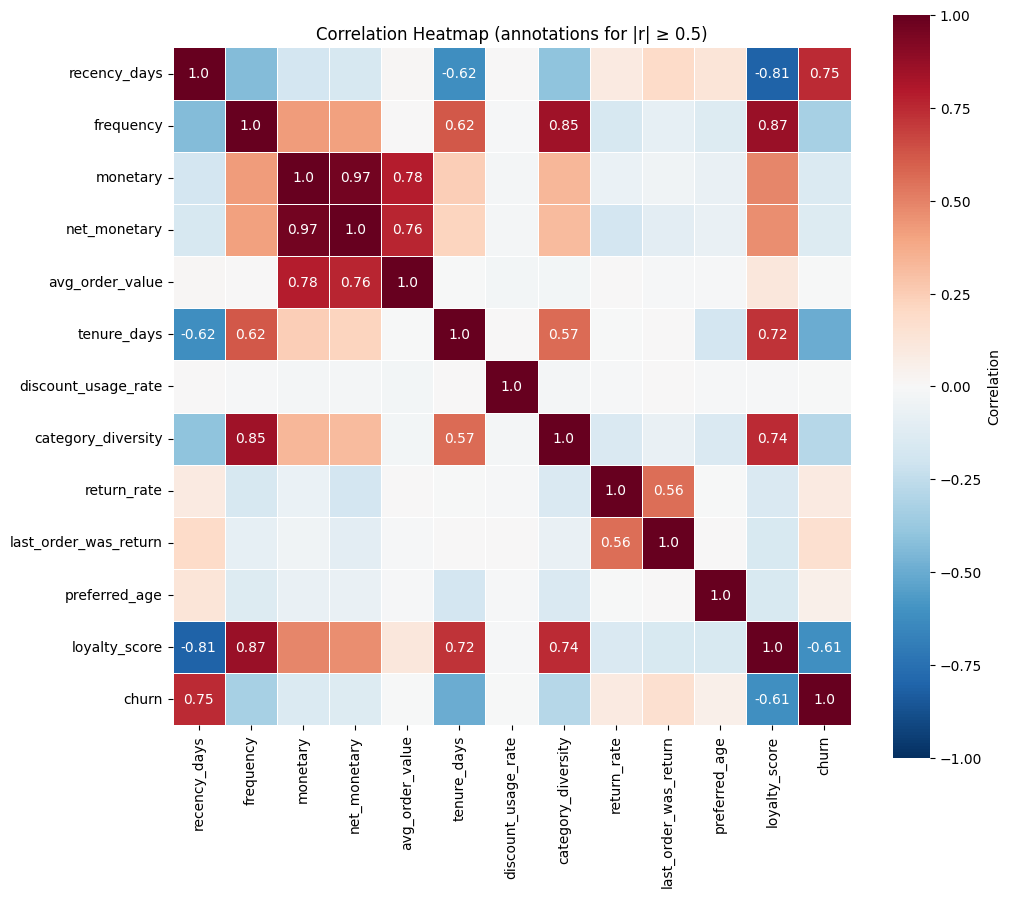

[4be2aa58] 2026-02-27 00:29:33 - n1e_viz_exploration_utils - INFO - Correlation heatmap complete


                              CORRELATION ANALYSIS                              

Strong Correlations (|r| > 0.5):
--------------------------------------------------------------------------------
monetary             <-> net_monetary        : r =  0.967 (Positive)
  -> Expected: Monetary and net_monetary are related metrics
     Strong relationship confirms net_monetary calculation is correct

frequency            <-> loyalty_score       : r =  0.865 (Positive)
  -> Expected: validates loyalty score calculation (frequency component)
     Loyalty score correctly weights purchase frequency

frequency            <-> category_diversity  : r =  0.846 (Positive)
  -> Expected: more purchases = more category exploration
     Frequent buyers actively explore product catalogue
     * ACTION: Cross-sell strategies for high-frequency customers

recency_days         <-> loyalty_score       : r = -0.812 (Negative)
  -> Expected: validates loyalty score calculation (recency component)
     Loyalty s

In [11]:
corr_threshold = tests.get('correlation_threshold', 0.5)

from n1e_viz_exploration_utils import analyze_correlations, plot_correlation_heatmap

# Plot heatmap
plot_correlation_heatmap(
    rfm_df,
    save=True,
    show=True,
    annot_threshold=corr_threshold,
    subfolder=subfolder,
    run_id=RUN_ID
)

# Analyze with automated insights
correlation_results = analyze_correlations(
    rfm_df,
    threshold=corr_threshold,
    run_id=RUN_ID,
    verbose=True
)

### 5.5 EDA Synthesis & Forward Implications

Three findings from the EDA that should directly shape decisions in downstream notebooks:

**1. Non-normality is confirmed — non-parametric tests apply throughout.**
All four transaction variables fail normality (Shapiro-Wilk, p < 0.001). NB02 and NB03 should use Mann-Whitney U and Kruskal-Wallis exclusively. The mean AOV ($170.01) is nearly 3× the median ($56.82) — use median as the central measure for any customer-facing analysis.

**2. Two collinear feature pairs must be resolved before clustering.**
`monetary`/`net_monetary` (r = 0.967) and `frequency`/`loyalty_score` (r = 0.865) are near-duplicates. Using both from either pair would distort distance-based models. NB03 enters with `monetary` and `loyalty_score` as the selected representatives.

**3. Electronics revenue concentration is the most immediately actionable business risk.**
56.6% of total revenue from one category is not a modelling nuance — it's a structural exposure that exists independently of how customers are segmented or what churn model is used. Any strategic output from this pipeline should be stress-tested against a scenario where Electronics demand contracts.

## 6. Summary Statistics

Portfolio-level KPIs from the full cleaned dataset:

| Metric | Value | Context |
|---|---|---|
| Total revenue | **$5,865,293** | Net of returns |
| Return rate | **5.52%** | Within the healthy 5–10% benchmark |
| Avg discount | **4.93%** | 45.1% of orders carry a discount |
| Active customers | **7,877** | 26 pure-return customers excluded |
| Avg LTV (`monetary`) | **$695.26** | Mean; median substantially lower given skew |
| Avg loyalty score | **0.385** | Scale [0, 1] — majority in weak-to-moderate band |
| Avg tenure | **411 days** | ~13.7 months mean customer lifespan |
| Avg category diversity | **3.1 of 7** | Customers explore just under half the available catalogue |

The mean/median AOV ratio of **2.99×** is the clearest signal that high-value outliers are shaping portfolio averages — use median ($56.82) for any typical-customer analysis.

In [12]:
mean_median_thresh   = rules.get('mean_median_ratio_threshold', 1.5)
return_healthy_max   = rules.get('return_rate_healthy_max', 10.0)
return_above_avg_max = rules.get('return_rate_above_avg_max', 15.0)

print("=" * 80)
print("TRANSACTION DATA SUMMARY")
print("=" * 80)

total_revenue      = df_clean['total_amount'].sum()
avg_order_value    = df_clean['total_amount'].mean()
median_order_value = df_clean['total_amount'].median()

print(f"\nVolume Metrics:")
print(f"Total Transactions: {len(df_clean):,}")
print(f"Unique Customers: {df_clean['customer_id'].nunique():,}")
print(f"Date Range: {df_clean['order_date'].min().date()} → {df_clean['order_date'].max().date()}")
print(f"Days Covered: {(df_clean['order_date'].max() - df_clean['order_date'].min()).days} days")

print(f"\nRevenue Metrics:")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Avg Order Value: ${avg_order_value:.2f}")
print(f"Median Order Value: ${median_order_value:.2f}")
print(f"Mean/Median Ratio: {avg_order_value / median_order_value:.2f}x")

if (avg_order_value / median_order_value) > mean_median_thresh:
    print(f"High-value outliers significantly influence average")
    print(f"Use median for typical customer analysis")

print(f"\nOperational Metrics:")
return_rate  = df_clean['returned'].mean() * 100
print(f"Return Rate: {return_rate:.2f}%")
print(f"Avg Discount: {df_clean['discount'].mean()*100:.2f}%")
print(f"Orders with Discount: {(df_clean['discount'] > 0).mean()*100:.1f}%")

print(f"\nReturn Rate Benchmark:")
if return_rate > return_above_avg_max:
    print(f"ELEVATED: {return_rate:.1f}% exceeds healthy range (5-{return_healthy_max:.0f}%)")
elif return_rate > return_healthy_max:
    print(f"ABOVE AVERAGE: {return_rate:.1f}% higher than optimal")
else:
    print(f"HEALTHY: {return_rate:.1f}% within acceptable range (5-{return_healthy_max:.0f}%)")

print("=" * 80)


TRANSACTION DATA SUMMARY

Volume Metrics:
Total Transactions: 34,500
Unique Customers: 7,903
Date Range: 2023-09-12 → 2025-09-11
Days Covered: 730 days

Revenue Metrics:
Total Revenue: $5,865,293.00
Avg Order Value: $170.01
Median Order Value: $56.82
Mean/Median Ratio: 2.99x
High-value outliers significantly influence average
Use median for typical customer analysis

Operational Metrics:
Return Rate: 5.52%
Avg Discount: 4.93%
Orders with Discount: 45.1%

Return Rate Benchmark:
HEALTHY: 5.5% within acceptable range (5-10%)


In [13]:
loyalty_labels = nb1_cfg.get('loyalty_segments', {}).get('labels', ['Bronze', 'Silver', 'Gold', 'Platinum'])

print("=" * 80)
print("CUSTOMER RFM SUMMARY")
print("=" * 80)

print(f"\nCustomer Base Metrics:")
print(f"Total customers: {len(rfm_df):,}")
print(f"Pure-return customers: {rfm_df['recency_days'].isna().sum():,}")
print(f"Active customers: {(rfm_df['recency_days'].notna()).sum():,}")

print(f"\nRFM Metrics:")
print(f"Avg recency: {rfm_df['recency_days'].mean():.1f} days")
print(f"Median recency: {rfm_df['recency_days'].median():.1f} days")
print(f"Avg frequency: {rfm_df['frequency'].mean():.1f} orders")
print(f"Avg monetary: ${rfm_df['monetary'].mean():,.2f}")
print(f"Avg net monetary: ${rfm_df['net_monetary'].mean():,.2f}")
print(f"Avg loyalty score: {rfm_df['loyalty_score'].mean():.3f}")

print(f"\nBehavioral Metrics:")
print(f"Avg tenure: {rfm_df['tenure_days'].mean():.1f} days")
print(f"Avg discount usage: {rfm_df['discount_usage_rate'].mean()*100:.1f}%")
print(f"Avg category diversity: {rfm_df['category_diversity'].mean():.1f} categories")
print(f"Avg return rate: {rfm_df['return_rate'].mean()*100:.2f}%")
print(f"Customers whose last order was return: {rfm_df['last_order_was_return'].sum():,}")

print("\n" + "=" * 80)


CUSTOMER RFM SUMMARY

Customer Base Metrics:
Total customers: 7,903
Pure-return customers: 26
Active customers: 7,877

RFM Metrics:
Avg recency: 165.3 days
Median recency: 120.0 days
Avg frequency: 4.1 orders
Avg monetary: $695.26
Avg net monetary: $643.78
Avg loyalty score: 0.385

Behavioral Metrics:
Avg tenure: 411.1 days
Avg discount usage: 45.2%
Avg category diversity: 3.1 categories
Avg return rate: 5.49%
Customers whose last order was return: 436



## 7. Data Quality Gate

Automated 10-check assertion suite run across both output tables.

**Result: PASSED — 7 clean passes · 0 failures · 3 warnings**

The 3 warnings are benign dtype mismatches: `quantity`, `customer_age`, and `delivery_time_days` are stored as `int8` rather than the validator's expected `int64/32/16`. `int8` is value-valid for all three columns (ranges well within [−128, 127]) — no data loss, no downstream impact.

**One business-logic flag worth noting:** 310 items (0.90%) have `shipping_cost > total_amount`. Not corrected — deeply discounted low-price items can legitimately exhibit this pattern. Flagged for awareness.

In [14]:
from n1f_sanity_check_wrapper import comprehensive_data_check

check_results = comprehensive_data_check(
    df_clean=df_clean,
    rfm_df=rfm_df,
    config=config,
    run_id=RUN_ID,
    verbose=True
)

print(f"\n{'='*80}")
print("DATA QUALITY VALIDATION RESULTS".center(80))
print("=" * 80)
print(f"\nValidation Summary:")
print(f"Total Checks: {check_results['total_checks']}")
print(f"Passed: {check_results['passed_checks']}")
print(f"Failed: {check_results['failed_checks']}")
print(f"Warnings: {check_results['warning_checks']}")

# Quality gate: determine if data is production-ready
if check_results['all_passed']:
    print(f"\nDATA QUALITY GATE: PASSED")
    print(f"Data is ready for downstream analysis")
else:
    print(f"\nDATA QUALITY GATE: FAILED")
    print(f"Address issues before proceeding to production")

    if check_results['messages']:
        print(f"\nIssues Identified:")
        for msg in check_results['messages']:
            print(f"- {msg}")

print("=" * 80)

[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - INFO - SANITY CHECK: Data Wrangling Pipeline Validation
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - INFO - Transaction data shape: 34,500 rows x 17 columns
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - INFO - ------------------------------------------------------------
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - INFO - VALIDATING DATA TYPES:
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - WARNING - Column 'quantity' has type int8, expected one of ['int64', 'int32', 'int16']
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - WARNING - Column 'customer_age' has type int8, expected one of ['int64', 'int32', 'int16']
[4be2aa58] 2026-02-27 00:29:33 - n1f_sanity_check - WARNING 


                        DATA QUALITY VALIDATION RESULTS                         

Validation Summary:
Total Checks: 10
Passed: 7
Failed: 0
Warnings: 3

DATA QUALITY GATE: PASSED
Data is ready for downstream analysis


## 8. Persist Outputs

Two files serialised, schema-verified, and logged against the current run ID for lineage tracing:

| File | Dimensions | Size |
|---|---|---|
| `enhanced_df.parquet` | 34,500 × 17 | 1.06 MB |
| `rfm_df.parquet` | 7,903 × 17 | 0.33 MB |

Post-write row and column counts verified before the pipeline exits. Both files hash-verified for downstream integrity checks.

In [15]:
from n1g_data_saver import save_processed_data

saved_files = save_processed_data(
    df=df_clean,
    rfm_df=rfm_df,
    run_id=RUN_ID,
    verbose=True
)

print(f"\n{'='*80}")
print("PIPELINE OUTPUTS".center(80))
print("=" * 80)
print("Data Files Ready:")
for name, filepath in saved_files.items():
    file_size = filepath.stat().st_size / 1024 / 1024
    print(f"{name:12s}: {filepath.name} ({file_size:.2f} MB)")


[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - Saving Processed Datasets
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - ============================================================
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - Output directory: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project\data\processed
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - Saving enhanced transaction dataset...
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - File saved: enhanced_df.parquet
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - Verified: 34,500 rows × 17 columns
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - File size: 1.06 MB
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - Enhanced dataset saved and verified
[4be2aa58] 2026-02-27 00:29:33 - n1g_data_saver - INFO - Saving RF


                                PIPELINE OUTPUTS                                
Data Files Ready:
enhanced    : enhanced_df.parquet (1.06 MB)
rfm         : rfm_df.parquet (0.33 MB)


## 9. Pipeline Complete

**`enhanced_df.parquet` and `rfm_df.parquet` are validated and persisted.**

| Downstream notebook | Consumes | Purpose |
|---|---|---|
| NB02 — Sales Analysis | `enhanced_df.parquet` | Temporal trends, category analysis, ARIMA forecasting |
| NB03 — Segmentation | `rfm_df.parquet` | RFM-based k-means clustering |
| NB04 — Churn | `enhanced_df.parquet` | Churn feature engineering and prediction |
| NB05 — Fraud | `enhanced_df.parquet` + `rfm_df.parquet` | Behavioural fraud scoring |
| NB06 — Cohort Retention  | `enhanced_df.parquet` + `rfm_df.parquet`| LTV regression modelling |

Pipeline is fully deterministic under `random_state = 42` — a clean re-run produces identical outputs.

In [16]:
# Pipeline completion summary
print("=" * 80)
print("NOTEBOOK 01 COMPLETE".center(80))
print("=" * 80)
print(f"\nRun ID: {RUN_ID}")
print(f"\nOutputs saved:")
print(f"1. enhanced_df.parquet - {len(df_clean):,} transactions")
print(f"2. rfm_df.parquet - {len(rfm_df):,} customers with RFM features")
print(f"\nKey metrics:")
print(f"- Total revenue: ${df_clean['total_amount'].sum():,.2f}")
print(f"- Avg customer lifetime value: ${rfm_df['monetary'].mean():.2f}")
print(f"- Avg loyalty score: {rfm_df['loyalty_score'].mean():.3f}")
print(f"- Return rate: {df_clean['returned'].mean()*100:.2f}%")
print("\nReady for downstream analysis.")
print("=" * 80)


                              NOTEBOOK 01 COMPLETE                              

Run ID: 4be2aa58

Outputs saved:
1. enhanced_df.parquet - 34,500 transactions
2. rfm_df.parquet - 7,903 customers with RFM features

Key metrics:
- Total revenue: $5,865,293.00
- Avg customer lifetime value: $695.26
- Avg loyalty score: 0.385
- Return rate: 5.52%

Ready for downstream analysis.
